# Unemployment Analysis with Python
### Objective: Explore regional and temporal unemployment trends in India, with focus on COVID-19 impact.

### IMPORTS

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

### Load Data

In [5]:
df = pd.read_csv("Unemployment_in_India.csv")
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


### Shape,info,null check

In [6]:
print("Shape:", df.shape)
print("\nColumn names (raw):", df.columns.tolist())

df.info()

print("\nNull values per column:")
print(df.isnull().sum())

Shape: (768, 7)

Column names (raw): ['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)', ' Estimated Employed', ' Estimated Labour Participation Rate (%)', 'Area']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB

Null values per colum

In [7]:
# Strip whitespace from column names
df.columns = df.columns.str.strip()

# Drop fully blank rows (the raw file has some empty rows)
df = df.dropna(how='all').reset_index(drop=True)

print("Shape after dropping blank rows:", df.shape)
print(df.columns.tolist())

Shape after dropping blank rows: (740, 7)
['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area']


In [8]:
df = df.rename(columns={
    'Region': 'Region',
    'Date': 'Date',
    'Frequency': 'Frequency',
    'Estimated Unemployment Rate (%)': 'Unemployment_Rate',
    'Estimated Employed': 'Employed',
    'Estimated Labour Participation Rate (%)': 'Labour_Participation_Rate',
    'Area': 'Area'
})
df.head()

,Region,Date,Frequency,Unemployment_Rate,Employed,Labour_Participation_Rate,Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [9]:
# Strip whitespace from string/object columns (fixes issues like ' Monthly' vs 'Monthly')
str_cols = df.select_dtypes(include='object').columns
for col in str_cols:
    df[col] = df[col].astype(str).str.strip()

# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Convert categorical columns
df['Region'] = df['Region'].astype('category')
df['Frequency'] = df['Frequency'].astype('category')
df['Area'] = df['Area'].astype('category')

# Ensure numeric columns are correct dtype
df['Unemployment_Rate'] = pd.to_numeric(df['Unemployment_Rate'], errors='coerce')
df['Employed'] = pd.to_numeric(df['Employed'], errors='coerce')
df['Labour_Participation_Rate'] = pd.to_numeric(df['Labour_Participation_Rate'], errors='coerce')

df.dtypes

Region                             category
Date                         datetime64[ns]
Frequency                          category
Unemployment_Rate                   float64
Employed                            float64
Labour_Participation_Rate           float64
Area                               category
dtype: object

**Observation:** After cleaning, blank rows have been removed and whitespace inconsistencies in text columns (like Frequency) are fixed. The dataset spans **May 2019 to June 2020**, giving us roughly 10 months of pre-COVID data and about 3 months of COVID-lockdown data — ideal for a before/after comparison.

In [24]:
region_avg = df.groupby('Region', observed=True)['Unemployment_Rate'].mean().sort_values(ascending=False)
region_avg.index = region_avg.index.astype(str)   # drop unused category labels
region_avg

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Punjab              12.031071
Puducherry          10.215000
Kerala              10.123929
Tamil Nadu           9.284286
Goa                  9.274167
Chhattisgarh         9.240357
West Bengal          8.124643
Telangana            7.737857
Maharashtra          7.557500
Andhra Pradesh       7.477143
Madhya Pradesh       7.406429
Sikkim               7.249412
Karnataka            6.676071
Gujarat              6.663929
Uttarakhand          6.582963
Assam                6.428077
Odisha               5.657857
Meghalaya            4.798889
Name: Unemployment_Rate, dtype: float64

In [11]:
df['Month'] = df['Date'].dt.to_period('M')
month_avg = df.groupby('Month')['Unemployment_Rate'].mean()
month_avg

Month
2019-05     8.874259
2019-06     9.303333
2019-07     9.033889
2019-08     9.637925
2019-09     9.051731
2019-10     9.900909
2019-11     9.868364
2019-12     9.497358
2020-01     9.950755
2020-02     9.964717
2020-03    10.700577
2020-04    23.641569
2020-05    24.875294
2020-06    11.903600
Freq: M, Name: Unemployment_Rate, dtype: float64

**Observation:** Region-wise averages show which states had structurally higher unemployment even before COVID-19. The month-wise trend should show a sharp jump starting around March-April 2020, aligning with India's nationwide lockdown.

### Time-Series Line Chart

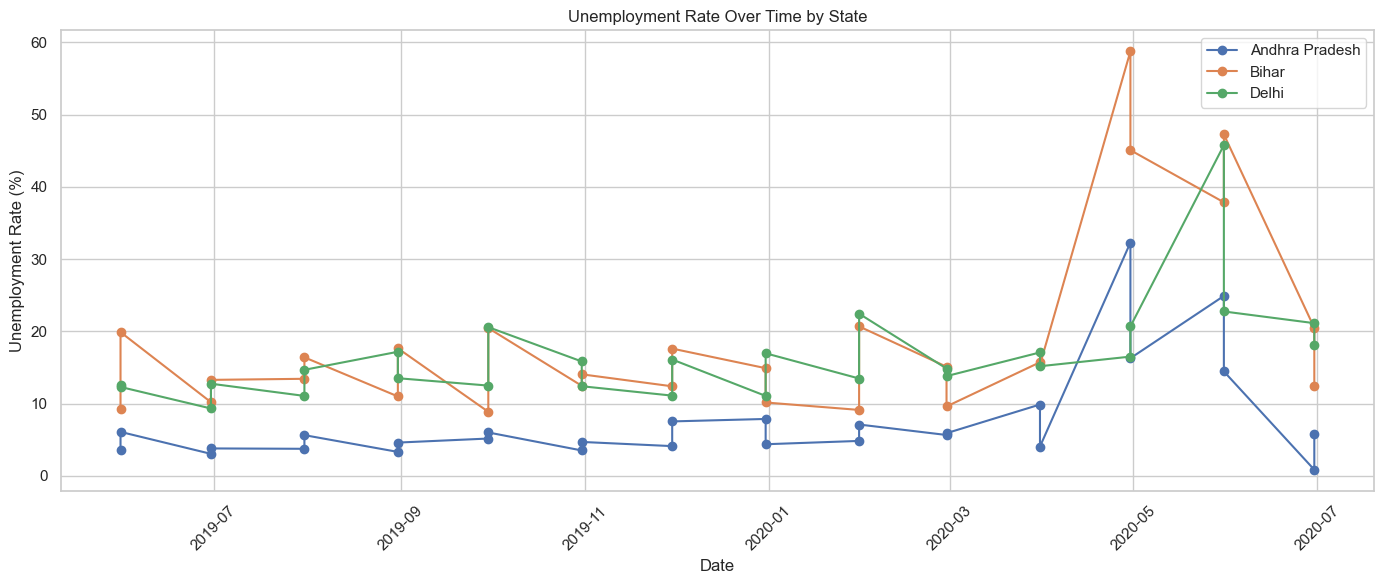

In [12]:
# Check available regions first if needed: df['Region'].unique()
states = ['Andhra Pradesh', 'Bihar', 'Delhi']

plt.figure(figsize=(14, 6))
for state in states:
    subset = df[df['Region'] == state].sort_values('Date')
    plt.plot(subset['Date'], subset['Unemployment_Rate'], marker='o', label=state)

plt.title('Unemployment Rate Over Time by State')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Observation:** All selected states show a sharp spike in unemployment around April 2020, coinciding with India's nationwide COVID-19 lockdown, followed by a partial recovery in the following months.

### Bar-Chart

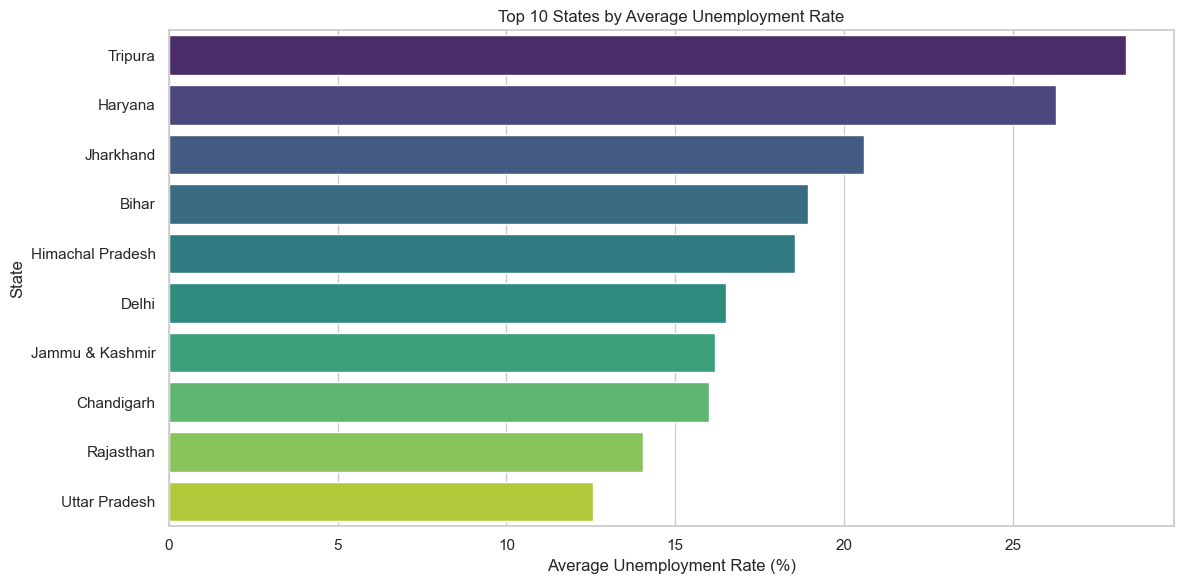

In [25]:
top10 = region_avg.head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top10.values, y=top10.index, hue=top10.index, palette='viridis', legend=False)
plt.title('Top 10 States by Average Unemployment Rate')
plt.xlabel('Average Unemployment Rate (%)')
plt.ylabel('State')
plt.tight_layout()
plt.show()

**Observation:** States at the top of this list have the highest average unemployment rate across the full data period (which includes the COVID spike), highlighting regions most affected overall.

### Correlation Heatmap

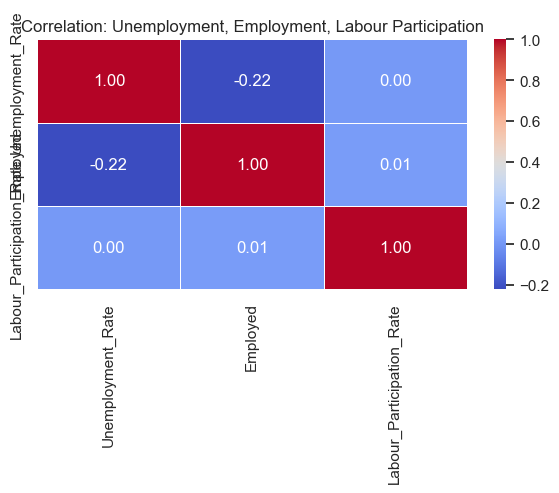

In [14]:
corr_cols = ['Unemployment_Rate', 'Employed', 'Labour_Participation_Rate']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation: Unemployment, Employment, Labour Participation')
plt.tight_layout()
plt.show()

**Observation:** Unemployment rate typically shows a negative correlation with the number of people employed, confirming the expected inverse relationship. Its relationship with labour participation rate tends to be weaker, since participation reflects willingness to work, not just job availability.

### Pre-COVID vs Post-COVID Split

In [15]:
covid_cutoff = pd.Timestamp('2020-03-25')  # India lockdown start date

pre_covid = df[df['Date'] < covid_cutoff]
post_covid = df[df['Date'] >= covid_cutoff]

comparison = pd.DataFrame({
    'Pre-COVID Mean (%)': [pre_covid['Unemployment_Rate'].mean()],
    'Post-COVID Mean (%)': [post_covid['Unemployment_Rate'].mean()]
})
comparison

,Pre-COVID Mean (%),Post-COVID Mean (%)
0,9.509534,17.774363


### Region-wise Pre vs Post Comparison

In [22]:
pre_region = pre_covid.groupby('Region', observed=True)['Unemployment_Rate'].mean()
post_region = post_covid.groupby('Region', observed=True)['Unemployment_Rate'].mean()

region_comparison = pd.DataFrame({'Pre-COVID': pre_region, 'Post-COVID': post_region}).dropna()
region_comparison['Change'] = region_comparison['Post-COVID'] - region_comparison['Pre-COVID']
region_comparison.sort_values('Change', ascending=False)

,Pre-COVID,Post-COVID,Change
Region,,,
Puducherry,1.593000,38.955000,37.362000
Tamil Nadu,2.836500,25.403750,22.567250
Jharkhand,14.279500,36.348750,22.069250
Bihar,13.833000,31.631250,17.798250
Karnataka,3.234500,15.280000,12.045500
Haryana,22.935500,34.652500,11.717000
Kerala,6.992500,17.952500,10.960000
Telangana,4.656000,15.442500,10.786500
Madhya Pradesh,4.741000,14.070000,9.329000


###  Bar Chart: Pre vs Post COVID

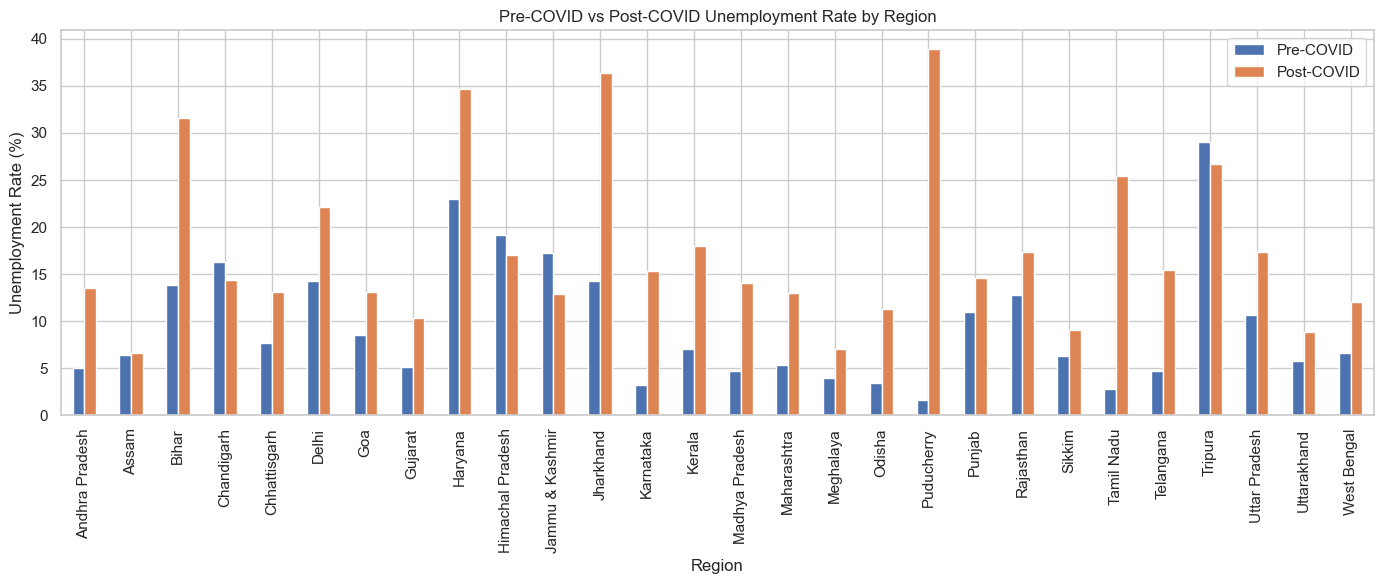

In [17]:
region_comparison[['Pre-COVID', 'Post-COVID']].plot(kind='bar', figsize=(14, 6))
plt.title('Pre-COVID vs Post-COVID Unemployment Rate by Region')
plt.ylabel('Unemployment Rate (%)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Rural vs Urban Comparison

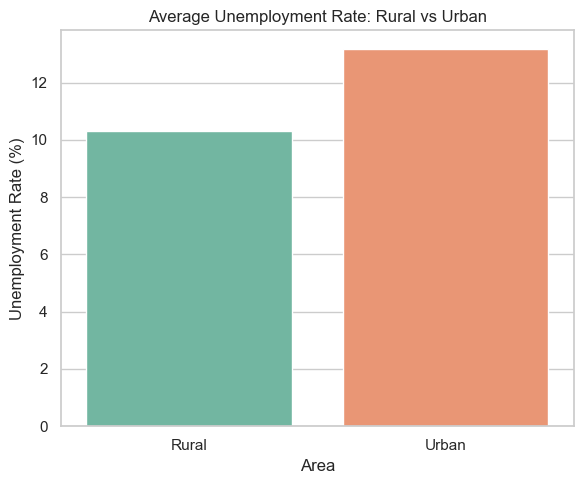

Area
Rural    10.324791
Urban    13.166614
Name: Unemployment_Rate, dtype: float64

In [23]:
area_comparison = df.groupby('Area', observed=True)['Unemployment_Rate'].mean()

plt.figure(figsize=(6, 5))
sns.barplot(x=area_comparison.index, y=area_comparison.values, hue=area_comparison.index, palette='Set2', legend=False)
plt.title('Average Unemployment Rate: Rural vs Urban')
plt.ylabel('Unemployment Rate (%)')
plt.tight_layout()
plt.show()

area_comparison

## Conclusion
- Unemployment rates varied significantly across Indian states even before COVID-19.
- A sharp nationwide spike occurred following the March 2020 lockdown.
- States with high pre-COVID unemployment often saw the steepest increases post-COVID.
- Employment and labour participation rates moved inversely with unemployment, as expected.
- Rural and urban areas were affected differently, offering additional insight into the pandemic's uneven impact.